# Approximating double n-capture

We want to approximate the sequence $A(n,\gamma)X(n,\gamma)B$ as $A(nn,\gamma)B$ by combining the two successive neutron captures into a single rate, assuming equilibrium of nucleus $X$.

This type of approximation is commonly done in the "aprox" family of networks, for example, approximating the sequence:
${}^{52}\mathrm{Fe}(n,\gamma){}^{53}\mathrm{Fe}(n,\gamma){}^{54}\mathrm{Fe}$.

In [1]:
import pynucastro as pyna
import matplotlib.pyplot as plt
import numpy as np

SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 22
MAJOR_TICK_SIZE = 5
MINOR_TICK_SIZE = 3

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('xtick.major', size=MAJOR_TICK_SIZE, width=1.5)
plt.rc('xtick.minor', size=MINOR_TICK_SIZE, width=1)
plt.rc('ytick.major', size=MAJOR_TICK_SIZE, width=1.5)
plt.rc('ytick.minor', size=MINOR_TICK_SIZE, width=1)
plt.rcParams.update({'lines.linewidth': 2.5})

## Unapproximated version

We'll create a simple network of iron isotopes linked by neutron capture.

In [2]:
rl = pyna.ReacLibLibrary()
lib = rl.linking_nuclei(["fe52", "fe53", "fe54", "n"])

In [3]:
net = pyna.PythonNetwork(libraries=[lib])

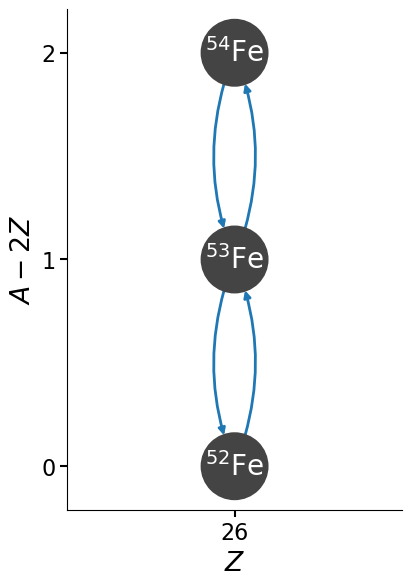

In [4]:
fig = net.plot(rotated=True, curved_edges=True, node_font_size=20, node_size=2200, size=(400, 600))
fig.savefig("double-n-capture-exact.pdf", bbox_inches="tight")

## Approximated version

We can use the helper function `create_double_neutron_capture()` to create a pair (forward and reverse) of `ApproximateRates` that approximate out the intermediate nucleus:

In [5]:
rf, rr = pyna.rates.create_double_neutron_capture(rl, pyna.Nucleus("fe52"), pyna.Nucleus("fe54"))

In [6]:
rf

Fe52 + n + n ⟶ Fe54 + 𝛾

We can see what rates this carries internally:

In [7]:
rf.hidden_rates

[Fe52 + n ⟶ Fe53 + 𝛾, Fe53 + n ⟶ Fe54 + 𝛾, Fe54 ⟶ n + Fe53, Fe53 ⟶ n + Fe52]

```{tip}
Alternately, we could use the `make_nn_g_approx()` method on the `PythonNetwork` once we create it.
```

Now we'll build a new network with just these approximate rates:

In [8]:
net_approx = pyna.PythonNetwork(rates=[rf, rr])

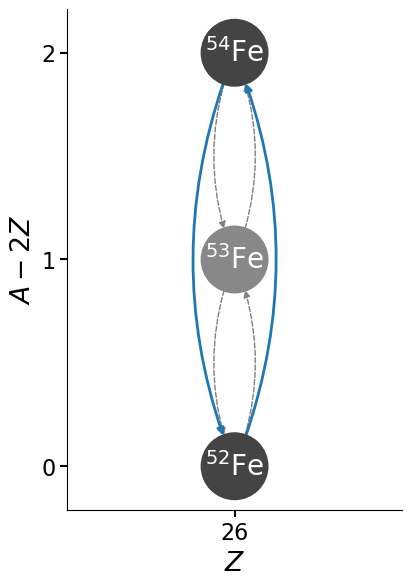

In [9]:
fig = net_approx.plot(rotated=True, curved_edges=True, node_font_size=20, node_size=2200, size=(400, 600))
fig.savefig("double-n-capture-approx.pdf", bbox_inches="tight")

## Comparison

Now let's integrate both networks and see how they compare.
First set the initial conditions used for integration. We will use a mix of ${}^{52}\mathrm{Fe}$ and $n$ for the initial composition

In [10]:
rho = 1.e9
T = 3.e9
tmax = 1.e-11

In [11]:
comp = pyna.Composition(net.unique_nuclei, small=0.0)
comp.X[pyna.Nucleus("n")] = 0.5
comp.X[pyna.Nucleus("Fe52")] = 0.5
Y0 = comp.get_molar_array()

In [12]:
approx_comp = pyna.Composition(net_approx.unique_nuclei, small=0.0)
approx_comp.X[pyna.Nucleus("n")] = 0.5
approx_comp.X[pyna.Nucleus("Fe52")] = 0.5
approx_Y0 = approx_comp.get_molar_array()

Now let's integrate both networks under the same condition.

In [13]:
sol = net.integrate_network(tmax, rho, T, Y0, rtol=1.e-8, atol=1.e-10)
sol_approx = net_approx.integrate_network(tmax, rho, T, approx_Y0, rtol=1.e-8, atol=1.e-10)

Now let's plot the evolution together to see how they compare

/tmp/ipykernel_120859/505768125.py:41: RuntimeWarning: invalid value encountered in divide
  rel_err = np.abs(X_approx - X_ref) / X_ref
/tmp/ipykernel_120859/505768125.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


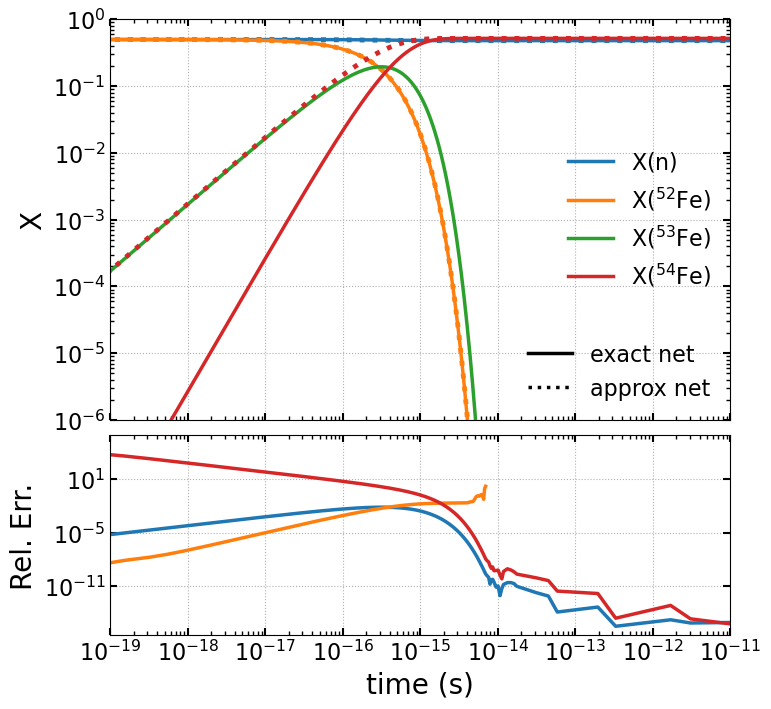

In [23]:
fig, (ax, ax_err) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 1], "hspace": 0.05})

# Top Panel
for i, nuc in enumerate(sol.unique_nuclei):
    ax.loglog(sol.t, sol.X[i, :],
              label=rf"X$({nuc.pretty})$",              
              linestyle="-", color=f"C{i}", linewidth=2.5)
    try:
        idx = sol_approx.unique_nuclei.index(nuc)
        ax.loglog(sol_approx.t, sol_approx.X[idx, :],
                  linestyle=":", color=f"C{i}", linewidth=3.5)
    except:
        continue

ax.set_ylim(1.e-6, 1)
ax.set_xlim(1.e-19, 1.e-11)
ax.set_ylabel("X")
ax.grid(ls=":")

# Add species legend
species_legend = ax.legend(loc="right", frameon=False)
ax.add_artist(species_legend)

# Add line legend
style_legend = [
    plt.Line2D([0], [0], color="k", linestyle="-", label="exact net"),
    plt.Line2D([0], [0], color="k", linestyle=":", label="approx net"),
]
ax.legend(handles=style_legend, loc="lower right", frameon=False)

# Bot panel for plotting error between common species
X_FLOOR = 1.e-10
for i, nuc in enumerate(sol_approx.unique_nuclei):
    idx = sol.unique_nuclei.index(nuc)
    X_ref = sol.X[idx, :]
    X_approx = sol_approx.X_at(sol.t)[i, :]

    # Only compute error for X greater than absolute tolerance of the integrator
    invalid = X_ref < X_FLOOR
    rel_err = np.abs(X_approx - X_ref) / X_ref
    rel_err[invalid] = np.nan
    
    ax_err.loglog(sol.t, rel_err,
              label=rf"X$({nuc.pretty})$",              
              linestyle="-", color=f"C{idx}", linewidth=2.5)

ax_err.set_xlabel("time (s)")
ax_err.set_ylabel("Rel. Err.")
ax_err.grid(ls=":")

for a in (ax, ax_err):
    a.minorticks_on()
    a.tick_params(top=True, bottom=True,
                  left=True, right=True,
                  direction="in", which="both")

fig.tight_layout()
fig.savefig("double-n-capture-integration.pdf", bbox_inches="tight")

Here the dotted line is the approximate version.  

We see that the ${}^{52}\mathrm{Fe}$ is consumed at the same rate for both networks. The early production of ${}^{54}\mathrm{Fe}$ in the approximate net is closely aligned with the production of ${}^{53}\mathrm{Fe}$ in the exact net.  As ${}^{53}\mathrm{Fe}$ reaches a steady state at $\sim 10^{-15}$ s, production of ${}^{54}\mathrm{Fe}$ from the approximate net becomes consistent with the exact net.